# P3 · 00 — A forecast without uncertainty is a guess

A point forecast says "GDP will be ₹X". A **probabilistic** forecast says "₹X, and
I'm 90% sure it's between ₹L and ₹H." Decisions need the second kind — capacity,
risk, budgets all hinge on the *range*, not the midpoint.

Three things make an interval *good*, and we need a number for each:

| property | question | metric |
|----------|----------|--------|
| **calibration** | does a 90% interval actually contain truth 90% of the time? | **coverage** |
| **sharpness** | is it tight enough to be useful? | **mean width** |
| **both at once** | the honest overall score | **Winkler / interval score** |

You can't chase coverage alone (a ±∞ interval covers 100% and is useless) or width
alone (a zero-width interval is sharp and always wrong). The **Winkler score**
combines them and is a *proper* score — you minimise it by being honest.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import classical as C, probabilistic as P
q = data.load_quarterly(); y = q["gdp_nsa"]
alpha = 0.10                      # -> 90% intervals

### Are our P1/P2 intervals actually calibrated? (backtest them)

We already have two interval producers: SARIMA's **model-based Gaussian-in-log**
interval (P1) and LightGBM **quantile regression** (P2). Let's measure their real
out-of-sample coverage with a rolling-origin **interval** backtest.

In [2]:
methods = {
    "SARIMA-Gaussian": P.parametric_interval_forecaster((1, 1, 1), (0, 1, 0, 4), alpha=alpha),
    "Quantile-GBM":    P.quantile_interval_forecaster(alpha=alpha),
}
rows = {}
for name, g in methods.items():
    df = P.rolling_origin_intervals(y, g, initial=40, h=4, step=1)
    rows[name] = P.summarize_intervals(df, alpha)
table = pd.DataFrame(rows).T
table["target"] = 1 - alpha
table.round({"coverage": 2, "target": 2, "mean_width": 0, "winkler": 0})

,coverage,target,mean_width,winkler
SARIMA-Gaussian,0.89,0.9,7815770.0,23840913.0
Quantile-GBM,0.82,0.9,20443334.0,32884514.0


Read it carefully — this is the whole point of the notebook:

* **SARIMA-Gaussian** lands near **0.89** coverage (≈ its 0.90 label) with the
  **narrowest** interval and the **best (lowest) Winkler**. Well-calibrated *and*
  sharp.
* **Quantile-GBM** **under-covers (~0.82–0.85)** *and* is much **wider** — worse on
  both axes, so its Winkler is far higher. A model can quote "90%" and simply be
  wrong; only the backtest reveals it.

> **Lesson:** nominal ≠ actual. Always *measure* coverage out-of-sample, and rank by
> a proper score (Winkler), never by eyeballing a fan chart.

### See one fold

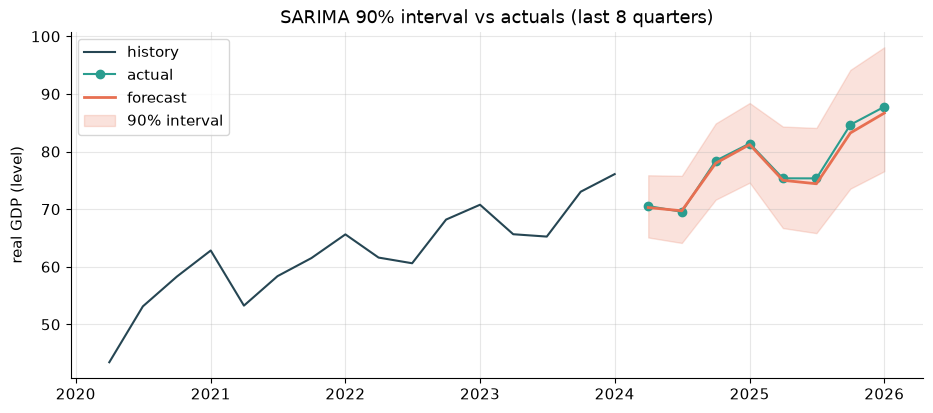

In [3]:
g = methods["SARIMA-Gaussian"]
df = P.rolling_origin_intervals(y, g, initial=len(y) - 8, h=8, step=1)  # last 8q
xt = [pd.Period(s, freq="Q").to_timestamp(how="start") for s in
      pd.period_range(y.index[-8], periods=8, freq="Q").astype(str)]
fig, ax = plt.subplots()
hist = y.iloc[-24:-8]
ax.plot(hist.index.to_timestamp(how="start"), hist.values / 1e6, color="#264653", label="history")
ax.plot(xt, df.y_true / 1e6, color="#2a9d8f", marker="o", label="actual")
ax.plot(xt, df["mean"] / 1e6, color="#e76f51", lw=2, label="forecast")
ax.fill_between(xt, df.lo / 1e6, df.hi / 1e6, color="#e76f51", alpha=0.2, label="90% interval")
ax.set(title="SARIMA 90% interval vs actuals (last 8 quarters)", ylabel="real GDP (level)")
ax.legend(); plt.show()

---
**Next (01):** the workhorse behind learned intervals — **quantile regression** —
its loss function, the **quantile-crossing** bug, and a **calibration diagram**.